# Introduction
This project harnesses the power of TensorFlow to develop a deep learning model that classifies 101 different classes of food images. This notebook documents the process that I took, which includes data preprocessing, the design of a convolutional neural network (CNN) using the Keras API, model training, and evaluation. By integrating best practices in computer vision, the project addresses challenges related to image variability and classification accuracy.

The primary objective is to build a CNN that outperforms the [DeepFood paper](https://arxiv.org/pdf/1606.05675.pdf) that achieved an accuracy score of 76.3% accuracy.

Through this project, I demonstrate my competency in using TensorFlow in to approach a computer vision project.

In [1]:
# Here, we read in custom functions to aid in the project
from helper_functions import create_tensorboard_callback, plot_loss_curves, compare_historys

## Get our Food-101 dataset
Our dataset resides in `tensorflow_datasets`. We will import the `tensorflow_datasets` package and use the `tfds.load` function to read in our data. I have set the `shuffle_files` parameter to False because I have already trained the model and I require the dataset to be unshuffled for model evaluation beyond the accuracy score obtained. For training, the `shuffle_files` parameter should be set to True because it prevents biased data ordering by ensuring diverse data views across batches, thus enhancing performance and speeding up convergence.

In [2]:
import tensorflow_datasets as tfds

In [5]:
# Check if our dataset is present
datasets_list = tfds.list_builders()
print("food101" in datasets_list)

True


In [4]:
# Load in our dataset
(train_data, test_data), ds_info = tfds.load(name='food101',
                                            split=['train', 'validation'],
                                            shuffle_files=False, # Change to True for training
                                            as_supervised=True,
                                            with_info=True)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...:   0%|          | 0/75750 [00:00<?, ? examples/s]

Shuffling /root/tensorflow_datasets/food101/incomplete.1LAYKI_2.0.0/food101-train.tfrecord*...:   0%|         …

Generating validation examples...:   0%|          | 0/25250 [00:00<?, ? examples/s]

Shuffling /root/tensorflow_datasets/food101/incomplete.1LAYKI_2.0.0/food101-validation.tfrecord*...:   0%|    …

Dataset food101 downloaded and prepared to /root/tensorflow_datasets/food101/2.0.0. Subsequent calls will reuse this data.


# Data Exploration
Following the data explorer's motto of "visualise, visualise, visualise", let's dive into understanding the data that we are working with.

In [6]:
# Features of Food101 from tfds
ds_info.features

FeaturesDict({
    'image': Image(shape=(None, None, 3), dtype=uint8),
    'label': ClassLabel(shape=(), dtype=int64, num_classes=101),
})

In [7]:
# Get class names (i.e the types of food) present in our dataset
class_names = ds_info.features['label'].names
class_names[:10]

['apple_pie',
 'baby_back_ribs',
 'baklava',
 'beef_carpaccio',
 'beef_tartare',
 'beet_salad',
 'beignets',
 'bibimbap',
 'bread_pudding',
 'breakfast_burrito']

In [8]:
# Take 1 sample of our train data to visualise it
train_one_sample = train_data.take(1)
train_one_sample

<_TakeDataset element_spec=(TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>

In [9]:
# Output info about our training set - we observe that there are varying shapes and our dtype should be float
for image, label in train_one_sample:
    print(f"""
    Image Shape: {image.shape}
    Image datatype: {image.dtype}
    Target Class (target form): {label}
    Class name: {class_names[label.numpy()]}
    """)


    Image Shape: (512, 512, 3)
    Image datatype: <dtype: 'uint8'>
    Target Class (target form): 56
    Class name: huevos_rancheros
    


In [10]:
# What does our image tensor look like?
image

<tf.Tensor: shape=(512, 512, 3), dtype=uint8, numpy=
array([[[233, 253, 251],
        [231, 253, 250],
        [228, 254, 251],
        ...,
        [ 85,  82,  89],
        [ 68,  67,  75],
        [ 57,  57,  67]],

       [[232, 254, 252],
        [229, 254, 251],
        [226, 255, 251],
        ...,
        [121, 116, 120],
        [100,  99, 104],
        [ 86,  85,  91]],

       [[228, 254, 253],
        [226, 255, 253],
        [223, 255, 252],
        ...,
        [164, 159, 155],
        [145, 141, 138],
        [128, 127, 125]],

       ...,

       [[ 66, 112, 164],
        [ 67, 113, 163],
        [ 55,  99, 148],
        ...,
        [  5,  14,  23],
        [  9,  18,  27],
        [  8,  17,  26]],

       [[ 76, 123, 177],
        [ 75, 122, 176],
        [ 70, 116, 168],
        ...,
        [  5,  14,  23],
        [  9,  18,  25],
        [  7,  16,  23]],

       [[ 80, 129, 185],
        [ 71, 121, 174],
        [ 74, 121, 175],
        ...,
        [  7,  16,  2

In [11]:
# Check the range of values in our tensor
import tensorflow as tf
tf.reduce_mean(image), tf.reduce_max(image)

(<tf.Tensor: shape=(), dtype=uint8, numpy=92>,
 <tf.Tensor: shape=(), dtype=uint8, numpy=255>)

The values of the tensors should ideally be between 0 and 1. However, the EfficientNet model that we will be using via transfer learning has a built-in scaling layer so we do not need to scale it when preprocessing our data.

Let's plot the image of our random sample:

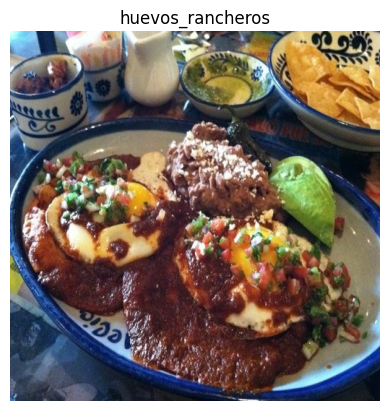

In [12]:
import matplotlib.pyplot as plt
plt.imshow(image)
plt.title(class_names[label.numpy()])
plt.axis(False);

# Data Preprocessing

What we know about our data:
- `uint8` datatype
- Different size images
- Not scaled

What we need to do:
- Convert to `float` type
- Standardise the image sizes
- Scale the tensor values between 0 and 1 (however since the EfficientNet model that we are going to use has a built-in rescaling layer, we do not need to include that in our function)

In [13]:
def preprocess_image(image, label, img_shape=224):
    image = tf.image.resize(image, size=[img_shape, img_shape])
    # image = image/255. #not required for efficientnet
    return tf.cast(image, tf.float32), label

In [14]:
# Test our function
preprocessed_image = preprocess_image(image, label)[0]

print(f'Image before preprocessing: \n {image[:2]}... \nShape: {image.shape}, \nDatatype: {image.dtype}')
print(f'Image after preprocessing: \n {preprocessed_image[:2]}... \nShape: {preprocessed_image.shape}, \nDatatype: {preprocessed_image.dtype}')

Image before preprocessing: 
 [[[233 253 251]
  [231 253 250]
  [228 254 251]
  ...
  [ 85  82  89]
  [ 68  67  75]
  [ 57  57  67]]

 [[232 254 252]
  [229 254 251]
  [226 255 251]
  ...
  [121 116 120]
  [100  99 104]
  [ 86  85  91]]]... 
Shape: (512, 512, 3), 
Datatype: <dtype: 'uint8'>
Image after preprocessing: 
 [[[230.65816 253.64285 251.     ]
  [222.99998 254.97449 252.19388]
  [207.06633 255.      250.36734]
  ...
  [140.66287 129.52519 121.22428]
  [121.14268 115.26515 116.95397]
  [ 83.95363  83.08119  89.63737]]

 [[221.47449 254.37755 253.33163]
  [214.5102  255.      253.92348]
  [198.41327 254.58673 251.96939]
  ...
  [208.66318 195.82143 173.40823]
  [197.03056 190.1071  174.83162]
  [175.54036 171.6169  161.21384]]]... 
Shape: (224, 224, 3), 
Datatype: <dtype: 'float32'>


## Batch and Process our Data

Batching is necessary for computational efficiency and ensures that we do not overload the GPU during training. We also incorporate pre-fetching to speed up training. Pre-fetching basically tells our computer to prepare the next batch of data for training while the current batch is training, as opposed to only fetching another batch once training on one batch is done.

In [30]:
# Map preprocessing function to training data and parallelise it
train_data = train_data.map(map_func=preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)

# Shuffle trained data and turn them into batches and pre-fetch it
train_data = train_data.shuffle(buffer_size=1000).batch(batch_size=32).prefetch(buffer_size=tf.data.AUTOTUNE)

# Map preprocessing to test data
test_data = test_data.map(map_func=preprocess_image, num_parallel_calls=tf.data.AUTOTUNE).batch(32).prefetch(tf.data.AUTOTUNE)

In [31]:
train_data, test_data

(<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>,
 <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>)

# Model Building

## Create modelling callbacks

In [16]:
# create modelcheckpoint callback to save model progress during training
checkpoint_path = 'model_checkpoints/cp.ckpt.weights.h5'
model_checkpoint = tf.keras.callbacks.ModelCheckpoint(checkpoint_path,
                                                     monitor='val_acc',
                                                     save_best_only=True,
                                                     save_weights_only=True,
                                                     verbose=0)

## Set up mixed-precision training
Mixed precision training involves using a mix of float16 and float32 tensors to make better use of the GPU's memory.

In [17]:
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy("mixed_float16")

In [18]:
mixed_precision.global_policy()

<DTypePolicy "mixed_float16">

## Build feature extraction model

In [19]:
from tensorflow.keras import layers
from tensorflow.keras import preprocessing

# Create base model
input_shape = (224, 224, 3)

base_model = tf.keras.applications.EfficientNetB0(include_top=False)
base_model.trainable = False

# Create functional model
inputs = layers.Input(shape=input_shape, name='input_layer')

# x=preprocessing.Rescaling(1/255.)(x)
x = base_model(inputs, training=False) # input layer
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(len(class_names))(x) # output layer
outputs = layers.Activation('softmax', dtype=tf.float32, name='softmax_float32')(x)
model = tf.keras.Model(inputs,outputs)

# Compile the model
model.compile(loss='sparse_categorical_crossentropy',
             optimizer=tf.keras.optimizers.Adam(),
             metrics=['accuracy'])

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [20]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ efficientnetb0 (Functional)          │ (None, 7, 7, 1280)          │       4,049,571 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 101)                 │         129,381 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ cast_1 (Cast)                        │ (None, 101)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ softmax_float32 (Activation)         │ (None, 101)                 │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,178,952 (15.94 MB)

 Trainable params: 129,381 (505.39 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [21]:
# Check if our layers are trainable - the base model is not trainable
for layer in model.layers:
    print(layer.name, layer.trainable, layer.dtype, layer.dtype_policy)

input_layer True float32 <DTypePolicy "mixed_float16">
efficientnetb0 False float32 <DTypePolicy "mixed_float16">
global_average_pooling2d True float32 <DTypePolicy "mixed_float16">
dense True float32 <DTypePolicy "mixed_float16">
softmax_float32 True float32 <DTypePolicy "float32">


In [22]:
# Let's take a look into the layers within the base model - the layers are, as expected, untrainable
for layer in model.layers[1].layers:
    print(layer.name, layer.trainable, layer.dtype, layer.dtype_policy)

input_layer False float32 <DTypePolicy "mixed_float16">
rescaling False float32 <DTypePolicy "mixed_float16">
normalization False float32 <DTypePolicy "mixed_float16">
rescaling_1 False float32 <DTypePolicy "mixed_float16">
stem_conv_pad False float32 <DTypePolicy "mixed_float16">
stem_conv False float32 <DTypePolicy "mixed_float16">
stem_bn False float32 <DTypePolicy "mixed_float16">
stem_activation False float32 <DTypePolicy "mixed_float16">
block1a_dwconv False float32 <DTypePolicy "mixed_float16">
block1a_bn False float32 <DTypePolicy "mixed_float16">
block1a_activation False float32 <DTypePolicy "mixed_float16">
block1a_se_squeeze False float32 <DTypePolicy "mixed_float16">
block1a_se_reshape False float32 <DTypePolicy "mixed_float16">
block1a_se_reduce False float32 <DTypePolicy "mixed_float16">
block1a_se_expand False float32 <DTypePolicy "mixed_float16">
block1a_se_excite False float32 <DTypePolicy "mixed_float16">
block1a_project_conv False float32 <DTypePolicy "mixed_float16"

## Fit the model
I have already trained the model and saved it, uncomment the code below for model training.

In [ ]:
# # Fit feature extarction model with callbacks
# history_101_classes_feature_extraction = model.fit(train_data,
#                                                    epochs=3,
#                                                    validation_data=test_data,
#                                                    validation_steps=int(0.2*len(test_data)),
#                                                    callbacks=[create_tensorboard_callback(dir_name="training_logs",
#                                                                                          experiment_name='efficientnetb0_101_feature_extract'),
#                                                              model_checkpoint])

In [ ]:
# results_feature_extract_model = model.evaluate(test_data)
# results_feature_extract_model

In [ ]:
# Save our model
# model.save("food_vision_model_1.keras")

In [25]:
# Load our model
food_vision_model_1_loaded = tf.keras.models.load_model("food_vision_model_1.keras")

/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'loss_scale_optimizer', because it has 8 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 4 variables whereas the saved optimizer has 6 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
# results_feature_extract_model_loaded = food_vision_model_1_loaded.evaluate(test_data)
# results_feature_extract_model_loaded

# Fine tuning our model
Our goal is to beat the [DeepFood paper](https://arxiv.org/pdf/1606.05675.pdf) performance of 76.3% accuracy. To do so, I un-froze our layers and engaged in fine-tuning. As a rule of thumb, we reduce the learning rate by 10x. To aid in the fine-tuning process, I introduced early stopping callbacks that would stop training if our validation loss does not decrease with more epochs, thereby reducing overfitting. I also included a callback to reduce the learning rate of our model if the loss reduction hits a plateau. This would help to optimise our model to squeeze out a bit more performance.

I have already fit the model and saved it. Un-comment the code below to fit it again.

In [ ]:
# Before fine tuning, let's set up an early-stopping callback
early_stopping_callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)

# We also set up a ModelCheckpoint callback so that we can save our best model while fine-tuning
fine_tuning_checkpoint_path = 'fine_tuning_checkpoint/fine_tune_cp.keras'
model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(fine_tuning_checkpoint_path,
                                                              monitor='val_loss',
                                                              save_best_only=True)

# Another callback we want to introduce is ReduceLROnPlateau
reduce_lr_callback = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss',
                                                         factor=0.2,
                                                         verbose=1,
                                                         min_lr=1e-7,
                                                         patience=2)

In [26]:
# # Compile our loaded model with a learning rate that is 10x smaller
food_vision_model_1_loaded.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(0.0001),
    metrics=['accuracy']
)

In [ ]:
# Check if our base model layers are trainable
# for layer in food_vision_model_1_loaded.layers[1].layers[:20]:
#     print(layer.name, layer.trainable, layer.dtype, layer.dtype_policy)

In [ ]:
# # Change all our base model layers to trainable layers
# for layer in food_vision_model_1_loaded.layers[1].layers:
#     layer.trainable = True # set all layers to trainable
#     print(layer.name, layer.trainable, layer.dtype, layer.dtype_policy)

In [ ]:
# Change last 10 layers to trainable layers
# for layer in food_vision_model_1_loaded.layers[1].layers[:-10]:
#     layer.trainable = False # set all other layers to untrainable
#     print(layer.name, layer.trainable, layer.dtype, layer.dtype_policy)

In [ ]:
# Great, they are all now trainable
# for layer in food_vision_model_1_loaded.layers[1].layers[-10:]:
#     print(layer.name, layer.trainable, layer.dtype, layer.dtype_policy)

In [ ]:
# # Fit and fine tune all our layers
# history_101_classes_feature_extraction_fine_tune = food_vision_model_1_loaded.fit(
#     train_data,
#     epochs=100,
#     validation_data=test_data,
#     validation_steps=int(0.15*(len(test_data))),
#     callbacks=[create_tensorboard_callback('training_logs','efficientnetb0_101_feature_extract_fine_tune'),
#               early_stopping_callback,
#               model_checkpoint_callback,
#               reduce_lr_callback]
# )

In [ ]:
# Evaluate our model
# food_vision_model_1_loaded.evaluate(test_data)

In [ ]:
# Save our fine-tuned model
# food_vision_model_1_loaded.save('food_vision_model_1_fine_tuned.keras')

In [27]:
# Load and evaluate our saved model
food_vision_model_1_fine_tuned_loaded = tf.keras.models.load_model('food_vision_model_1_fine_tuned.keras')

In [ ]:
food_vision_model_1_fine_tuned_loaded.evaluate(test_data)

790/790 ━━━━━━━━━━━━━━━━━━━━ 83s 82ms/step - accuracy: 0.8347 - loss: 0.6480


[0.6531949043273926, 0.8340989947319031]

Excellent! We managed to achieve an accuracy score of 83.4% which is 7.1 percentage points higher than the DeepFood paper. Let's visualise the model's performance next.

# Visualising model performance

We must first unravel our batched data.

In [32]:
test_data_unbatched = test_data.unbatch()

Then, we obtain the true labels from the test data set and consolidate all of them in a list.

In [33]:
y_labels = []

for images, labels in test_data_unbatched:
    y_labels.append(labels.numpy())

y_labels[:5]

[29, 81, 91, 53, 97]

We also make predictions using our model so that we can compare the predictions against the true labels.

In [34]:
pred_probs = food_vision_model_1_fine_tuned_loaded.predict(test_data)

pred_probs[:5]

790/790 ━━━━━━━━━━━━━━━━━━━━ 69s 72ms/step


array([[5.39024128e-04, 2.23634427e-08, 1.21843826e-07, 1.35641143e-08,
        1.87640887e-06, 7.50658060e-08, 3.72384761e-07, 2.44729881e-06,
        2.87928549e-03, 2.57478519e-06, 6.75720821e-06, 4.79879647e-09,
        7.16496834e-06, 4.05923092e-05, 1.36499366e-05, 9.84649162e-09,
        1.03151193e-04, 1.21405055e-05, 7.83381970e-10, 2.82190911e-07,
        6.76738798e-09, 2.82827059e-05, 3.13673045e-05, 9.54639518e-07,
        2.05218509e-08, 9.19725522e-08, 1.26469206e-06, 3.02246208e-05,
        5.07005268e-07, 9.81982350e-01, 5.05193195e-04, 1.23214937e-04,
        2.11732818e-08, 4.09600798e-10, 3.58848367e-04, 2.11288165e-09,
        8.49200842e-06, 2.71870348e-08, 6.50813359e-09, 1.18771357e-08,
        1.68808132e-08, 1.24471313e-08, 7.82437201e-05, 4.46357618e-10,
        6.52183090e-08, 5.14291599e-03, 2.56861066e-09, 8.40446213e-10,
        5.24043813e-08, 2.08888935e-07, 4.08125693e-08, 3.95569018e-08,
        6.11382545e-09, 1.49915231e-05, 6.16177642e-09, 3.833985

In [35]:
pred_classes = []

for i in pred_probs.argmax(axis=1):
    pred_classes.append(i)

pred_classes[:5]

[29, 81, 91, 53, 97]

In [36]:
# Note: The following confusion matrix code is a remix of Scikit-Learn's
# plot_confusion_matrix function - https://scikit-learn.org/stable/modules/generated/sklearn.metrics.plot_confusion_matrix.html
import itertools
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

def make_confusion_matrix(y_true, y_pred, classes=None, figsize=(10, 10), text_size=15, norm=False, savefig=False):

  # Create the confustion matrix
  cm = confusion_matrix(y_true, y_pred)
  cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis] # normalize it
  n_classes = cm.shape[0] # find the number of classes we're dealing with

  # Plot the figure and make it pretty
  fig, ax = plt.subplots(figsize=figsize)
  cax = ax.matshow(cm, cmap=plt.cm.Blues) # colors will represent how 'correct' a class is, darker == better
  fig.colorbar(cax)

  # Are there a list of classes?
  if classes:
    labels = classes
  else:
    labels = np.arange(cm.shape[0])

  # Label the axes
  ax.set(title="Confusion Matrix",
         xlabel="Predicted label",
         ylabel="True label",
         xticks=np.arange(n_classes), # create enough axis slots for each class
         yticks=np.arange(n_classes),
         xticklabels=labels, # axes will labeled with class names (if they exist) or ints
         yticklabels=labels)

  # Make x-axis labels appear on bottom
  ax.xaxis.set_label_position("bottom")
  ax.xaxis.tick_bottom()

  ### Added: Rotate xticks for readability & increase font size (required due to such a large confusion matrix)
  plt.xticks(rotation=70, fontsize=text_size)
  plt.yticks(fontsize=text_size)

  # Set the threshold for different colors
  threshold = (cm.max() + cm.min()) / 2.

  # Plot the text on each cell
  for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    if norm:
      plt.text(j, i, f"{cm[i, j]} ({cm_norm[i, j]*100:.1f}%)",
              horizontalalignment="center",
              color="white" if cm[i, j] > threshold else "black",
              size=text_size)
    else:
      plt.text(j, i, f"{cm[i, j]}",
              horizontalalignment="center",
              color="white" if cm[i, j] > threshold else "black",
              size=text_size)

  # Save the figure to the current working directory
  if savefig:
    fig.savefig("confusion_matrix.png")

In [ ]:
make_confusion_matrix(y_true=y_labels,
                      y_pred=pred_classes,
                      classes=class_names,
                      figsize=(100, 100),
                      text_size=20,
                      norm=False,
                      savefig=True)

We have a beautiful confusion matrix with most of the darker colours lying in the diagonal which should be the case given our high accuracy score.

However, it may be challenging to find out which food items our model gets confused on with this confusion matrix. Let's use the `classification_report` function to obtain the f1-scores and find out the top 5 best and worst performing food items.

In [38]:
from sklearn.metrics import classification_report
classification_report_dict = classification_report(y_labels, pred_classes, output_dict=True)
classification_report_dict

{'0': {'precision': 0.6966824644549763,
  'recall': 0.588,
  'f1-score': 0.6377440347071583,
  'support': 250.0},
 '1': {'precision': 0.813953488372093,
  'recall': 0.84,
  'f1-score': 0.8267716535433071,
  'support': 250.0},
 '2': {'precision': 0.8571428571428571,
  'recall': 0.888,
  'f1-score': 0.8722986247544204,
  'support': 250.0},
 '3': {'precision': 0.8367346938775511,
  'recall': 0.82,
  'f1-score': 0.8282828282828283,
  'support': 250.0},
 '4': {'precision': 0.7890625,
  'recall': 0.808,
  'f1-score': 0.7984189723320159,
  'support': 250.0},
 '5': {'precision': 0.8113207547169812,
  'recall': 0.688,
  'f1-score': 0.7445887445887446,
  'support': 250.0},
 '6': {'precision': 0.8543307086614174,
  'recall': 0.868,
  'f1-score': 0.8611111111111112,
  'support': 250.0},
 '7': {'precision': 0.9073359073359073,
  'recall': 0.94,
  'f1-score': 0.9233791748526523,
  'support': 250.0},
 '8': {'precision': 0.6978723404255319,
  'recall': 0.656,
  'f1-score': 0.6762886597938145,
  'suppo

From the dictionary that obtained above, we extract the f1-score and append it to a dictionary.

In [39]:
f1_scores = {}

for key, value in classification_report_dict.items():
    if key == 'accuracy':
        break
    else:
      f1_scores[class_names[int(key)]] = value['f1-score']

f1_scores

{'apple_pie': 0.6377440347071583,
 'baby_back_ribs': 0.8267716535433071,
 'baklava': 0.8722986247544204,
 'beef_carpaccio': 0.8282828282828283,
 'beef_tartare': 0.7984189723320159,
 'beet_salad': 0.7445887445887446,
 'beignets': 0.8611111111111112,
 'bibimbap': 0.9233791748526523,
 'bread_pudding': 0.6762886597938145,
 'breakfast_burrito': 0.7739307535641547,
 'bruschetta': 0.7975206611570248,
 'caesar_salad': 0.8533333333333334,
 'cannoli': 0.8764940239043825,
 'caprese_salad': 0.8244274809160306,
 'carrot_cake': 0.8090349075975359,
 'ceviche': 0.7045951859956237,
 'cheesecake': 0.720164609053498,
 'cheese_plate': 0.8518518518518519,
 'chicken_curry': 0.7683168316831683,
 'chicken_quesadilla': 0.8326693227091634,
 'chicken_wings': 0.9050505050505051,
 'chocolate_cake': 0.7325102880658436,
 'chocolate_mousse': 0.6563106796116505,
 'churros': 0.908,
 'clam_chowder': 0.9025844930417495,
 'club_sandwich': 0.8812877263581489,
 'crab_cakes': 0.7620967741935484,
 'creme_brulee': 0.9027237354

Turn f1-scores into a dataframe for visualization.

In [40]:
import pandas as pd
f1_scores = pd.DataFrame({"class_name": list(f1_scores.keys()),
                          "f1-score": list(f1_scores.values())}).sort_values("f1-score", ascending=False)
f1_scores.head()

,class_name,f1-score
33,edamame,0.998004
63,macarons,0.958416
75,pho,0.938614
64,miso_soup,0.934426
40,french_fries,0.932039


Finally, we plot the horizontal bar chart to visualise which are the food items that our model performs the best and the worst.

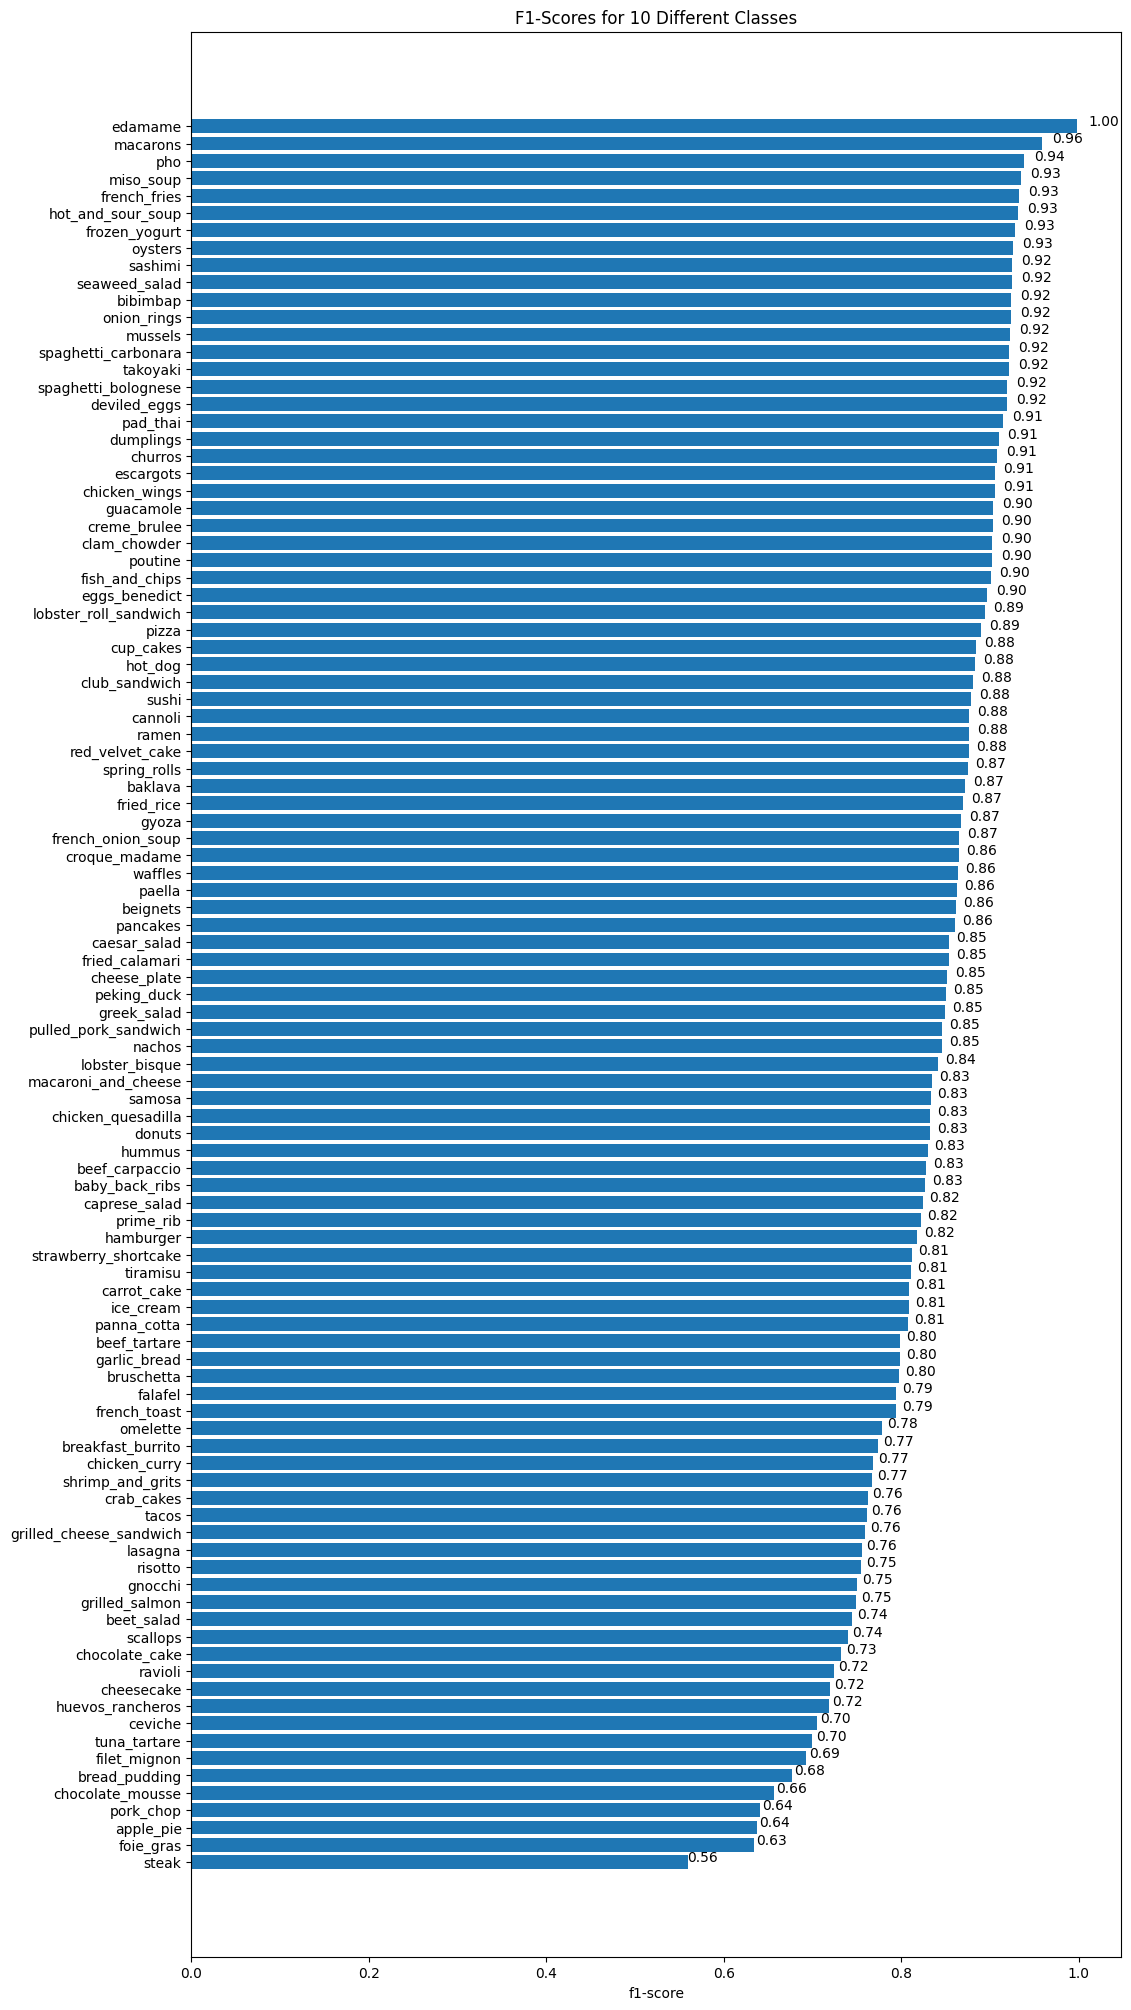

In [41]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 25))
scores = ax.barh(range(len(f1_scores)), f1_scores["f1-score"].values)
ax.set_yticks(range(len(f1_scores)))
ax.set_yticklabels(list(f1_scores["class_name"]))
ax.set_xlabel("f1-score")
ax.set_title("F1-Scores for 10 Different Classes")
ax.invert_yaxis(); # reverse the order

def autolabel(rects): # Modified version of: https://matplotlib.org/examples/api/barchart_demo.html
  """
  Attach a text label above each bar displaying its height (it's value).
  """
  for rect in rects:
    width = rect.get_width()
    ax.text(1.03*width, rect.get_y() + rect.get_height()/1.5,
            f"{width:.2f}",
            ha='center', va='bottom')

autolabel(scores)

It seems like our model does really well for edamame, macarons, pho, miso soup, and french fries. On the other hand, steak, foie gras, apple pie, and pork chop seem to confuse our model.

Perhaps, we could prepare more images of the poor-performing items to enhance our model further.

As a last model performance visualisation, let's make predictions on some images and visualise them.

In [43]:
from helper_functions import unzip_data
unzip_data("10_food_classes_all_data.zip")

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


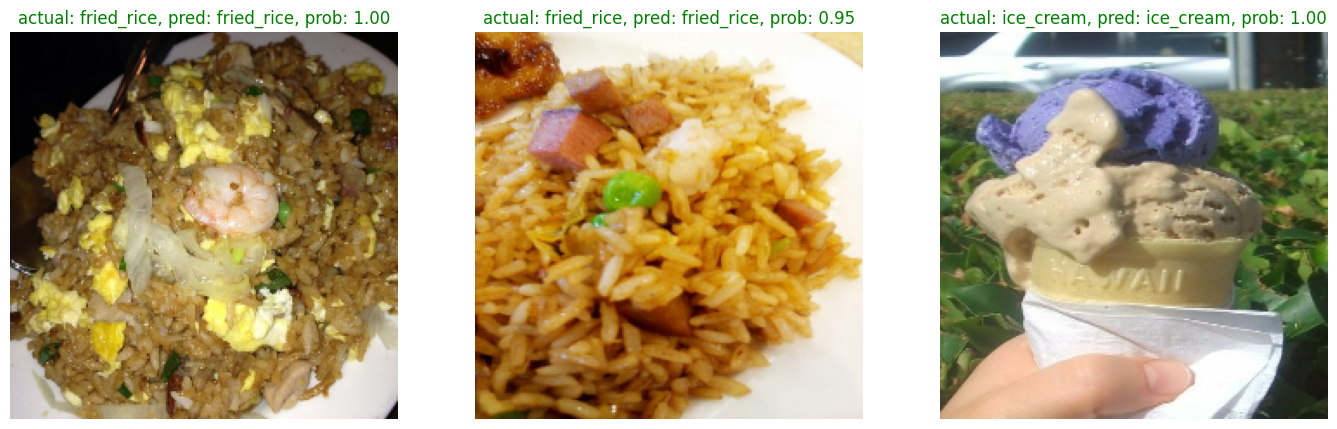

In [52]:
from helper_functions import load_and_prep_image
test_dir = '/content/10_food_classes_all_data/test/'
train_dir = '/content/10_food_classes_all_data/train/'

# Make preds on a series of random images
import os
import random

plt.figure(figsize=(17, 10))
for i in range(3):
  # Choose a random image from a random class
  class_names_subset = os.listdir(test_dir)
  class_name = random.choice(class_names_subset)
  filename = random.choice(os.listdir(test_dir + "/" + class_name))
  filepath = test_dir + class_name + "/" + filename

  # Load the image and make predictions
  img = load_and_prep_image(filepath, scale=False) # don't scale images for EfficientNet predictions
  pred_prob = food_vision_model_1_fine_tuned_loaded.predict(tf.expand_dims(img, axis=0)) # model accepts tensors of shape [None, 224, 224, 3]
  pred_class = class_names[pred_prob.argmax()] # find the predicted class

  # Plot the image(s)
  plt.subplot(1, 3, i+1)
  plt.imshow(img/255.)
  if class_name == pred_class: # Change the color of text based on whether prediction is right or wrong
    title_color = "g"
  else:
    title_color = "r"
  plt.title(f"actual: {class_name}, pred: {pred_class}, prob: {pred_prob.max():.2f}", c=title_color)
  plt.axis(False);

# Conclusion

We were able to achieve our goal of beating a benchmark from a research paper. We were also able to go through the machine learning project journey from data preparation all the way to model evaluation. In conclusion, leveraging TensorFlow for the Food-101 dataset demonstrates how deep learning architectures can effectively classify food images by extracting key visual features at scale. This project underscores both the power of convolutional neural networks in discerning subtle patterns across diverse food categories and the necessity of careful preprocessing, hyperparameter tuning, and robust evaluation. Future work could integrate more advanced model architectures, dataset augmentation, or domain-specific techniques to further refine classification accuracy.